In [1]:
from PIL import Image
import torch
import numpy as np
from BiomedParse.modeling.BaseModel import BaseModel
from BiomedParse.modeling import build_model
from BiomedParse.utilities.distributed import init_distributed
from BiomedParse.utilities.arguments import load_opt_from_config_files
from BiomedParse.utilities.constants import BIOMED_CLASSES

from BiomedParse.inference_utils.inference import interactive_infer_image
from BiomedParse.inference_utils.output_processing import check_mask_stats

/home/t-qimhuang/miniconda3/envs/biomedparse-main-eval/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/t-qimhuang/miniconda3/envs/biomedparse-main-eval/lib/python3.9/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Deformable Transformer Encoder is not available.


/home/t-qimhuang/miniconda3/envs/biomedparse-main-eval/lib/python3.9/site-packages/kornia/feature/lightglue.py:30: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


In [ ]:
import huggingface_hub

HF_TOKEN = ''

huggingface_hub.login(HF_TOKEN)

### Model Setup

In [2]:
# Build model config
opt = load_opt_from_config_files(["BiomedParse/configs/biomedparse_inference.yaml"])
opt = init_distributed(opt)

# Load model from pretrained weights
pretrained_pth = 'hf_hub:microsoft/BiomedParse'

model = BaseModel(opt, build_model(opt)).from_pretrained(pretrained_pth).eval().cuda()
with torch.no_grad():
    model.model.sem_seg_head.predictor.lang_encoder.get_text_embeddings(BIOMED_CLASSES + ["background"], is_eval=True)

$UNUSED$ criterion.empty_weight, Ckpt Shape: torch.Size([17])


### Utility Functions

In [3]:
def plot_segmentation_masks(original_image, segmentation_masks, texts):
    ''' Plot a list of segmentation mask over an image.
    '''
    original_image = original_image[:, :, :3]
    fig, ax = plt.subplots(1, len(segmentation_masks) + 1, figsize=(10, 5))
    ax[0].imshow(original_image, cmap='gray')
    ax[0].set_title('Original Image')
    # grid off
    for a in ax:
        a.axis('off')

    for i, mask in enumerate(segmentation_masks):
        
        ax[i+1].set_title(texts[i])
        mask_temp = original_image.copy()
        mask_temp[mask > 0.5] = [255, 0, 0]
        mask_temp[mask <= 0.5] = [0, 0, 0, ]
        ax[i+1].imshow(mask_temp, alpha=0.9)
        ax[i+1].imshow(original_image, cmap='gray', alpha=0.5)
        
    
    plt.show()

In [4]:
!pip install pydicom nibabel SimpleITK

import json
import matplotlib.pyplot as plt

from BiomedParse.inference_utils.processing_utils import read_rgb


def inference_rgb(file_path, text_prompts):
    image = read_rgb(file_path)
    
    pred_mask = interactive_infer_image(model, Image.fromarray(image), text_prompts)

    # Plot feature over image
    plot_segmentation_masks(image, pred_mask, text_prompts)
    
    return image, pred_mask


### Pathology Example

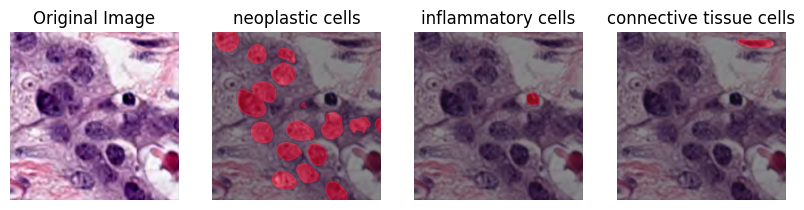

neoplastic cells P-value: 0.9291941724912619
inflammatory cells P-value: 0.43771858127098695
connective tissue cells P-value: 0.575110741081249


In [8]:
image_path = 'examples/CT_lung_nodule.dcm'
text_prompt = ['nodule']

image_path = 'examples/Part_1_516_pathology_breast.png'
text_prompt = ['neoplastic cells', 'inflammatory cells', 'connective tissue cells']

image, pred_mask = inference_rgb(image_path, text_prompt)

for i in range(len(pred_mask)):
    adj_pvalue = check_mask_stats(image, pred_mask[i]*255, 'Pathology', text_prompt[i])
    print(f'{text_prompt[i]} P-value: {adj_pvalue}')

#### Get Cell Instances

In [5]:
from BiomedParse.inference_utils.processing_utils import get_instances

def plot_instance_segmentation_masks(original_image, segmentation_masks, text_prompt=None):
    ''' Plot a list of segmentation mask over an image.
    '''
    original_image = original_image[:, :, :3]
    fig, ax = plt.subplots(1, len(segmentation_masks) + 1, figsize=(10, 5))
    ax[0].imshow(original_image, cmap='gray')
    ax[0].set_title('Original Image')
    # grid off
    for a in ax:
        a.axis('off')
        
    instance_masks = [get_instances(1*(mask>0.5)) for mask in segmentation_masks]
    
    mask_names = [f'Mask {i+1}' for i in range(len(segmentation_masks))]
    if text_prompt:
        mask_names = text_prompt
        for i in range(len(mask_names)):
            mask_names[i] = mask_names[i].strip()


    for i, mask in enumerate(instance_masks):
        ins_ids = np.unique(mask)
        count = len(ins_ids[ins_ids > 0])
        
        ax[i+1].set_title(f'{mask_names[i]} ({count})')
        mask_temp = np.zeros_like(original_image)
        for ins_id in ins_ids:
            if ins_id == 0:
                continue
            mask_temp[mask == ins_id] = np.random.randint(0, 255, 3)
            if ins_id == 1:
                mask_temp[mask == ins_id] = [255, 0, 0]
        
        ax[i+1].imshow(mask_temp, alpha=1)
        ax[i+1].imshow(original_image, cmap='gray', alpha=0.5)
        
        
    plt.show()

MaskImageFilter (0x7ffe30122430): Support for pixel type 32-bit unsigned integer for the MaskImage input has been deprecated and will be removed in future versions. Implicitly casting input to support 'sitkUInt8' type. MaskImageFilter (0x7ffe30122430): Support for pixel type 32-bit unsigned integer for the MaskImage input has been deprecated and will be removed in future versions. Implicitly casting input to support 'sitkUInt8' type. MaskImageFilter (0x7ffe30122430): Support for pixel type 32-bit unsigned integer for the MaskImage input has been deprecated and will be removed in future versions. Implicitly casting input to support 'sitkUInt8' type. 

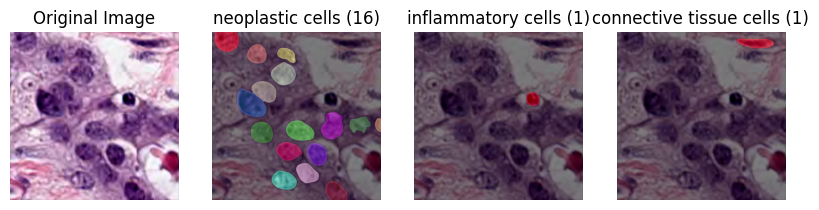

In [10]:
plot_instance_segmentation_masks(image, pred_mask, text_prompt)

### X-Ray Example

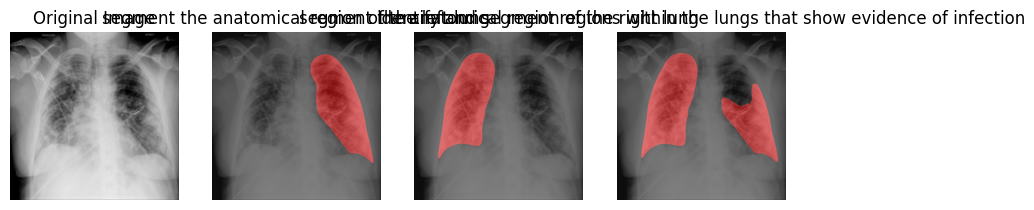

In [8]:
image_path = 'examples/covid_1585.png'
# text_prompt = ['left lung', 'right lung', 'COVID-19 infection']

text_prompt = [
    "segment the anatomical region of the left lung",
    "segment the anatomical region of the right lung",
    "identify and segment regions within the lungs that show evidence of infection"
]

image, pred_mask = inference_rgb(image_path, text_prompt)

# for i in range(len(pred_mask)-1):
#     adj_pvalue = check_mask_stats(image, pred_mask[i]*255, 'X-Ray-Chest', text_prompt[i])
#     print(f'{text_prompt[i]} P-value: {adj_pvalue}')

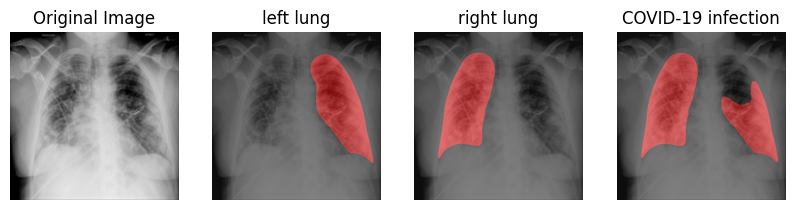

In [9]:
image_path = 'examples/covid_1585.png'
text_prompt = ['left lung', 'right lung', 'COVID-19 infection']

# text_prompt = [
#     "segment the anatomical region of the left lung",
#     "segment the anatomical region of the right lung",
#     "identify and segment regions within the lungs that show evidence of infection"
# ]

image, pred_mask = inference_rgb(image_path, text_prompt)

# for i in range(len(pred_mask)-1):
#     adj_pvalue = check_mask_stats(image, pred_mask[i]*255, 'X-Ray-Chest', text_prompt[i])
#     print(f'{text_prompt[i]} P-value: {adj_pvalue}')

### Fundus Example

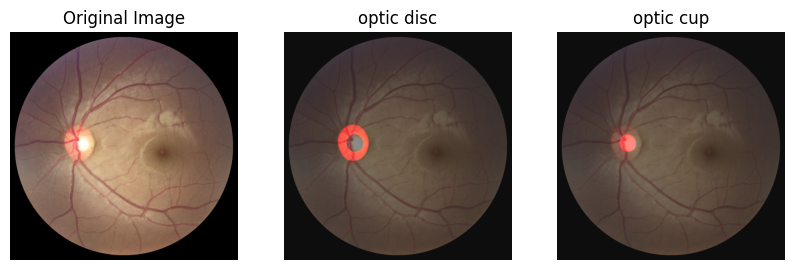

optic disc P-value: 0.6497367947168615
optic cup P-value: 0.5823149452634461


In [12]:
image_path = 'examples/T0011.jpg'
text_prompt = ['optic disc', 'optic cup']

image, pred_mask = inference_rgb(image_path, text_prompt)

for i in range(len(pred_mask)):
    adj_pvalue = check_mask_stats(image, pred_mask[i]*255, 'Fundus', text_prompt[i])
    print(f'{text_prompt[i]} P-value: {adj_pvalue}')

### Endoscope Example

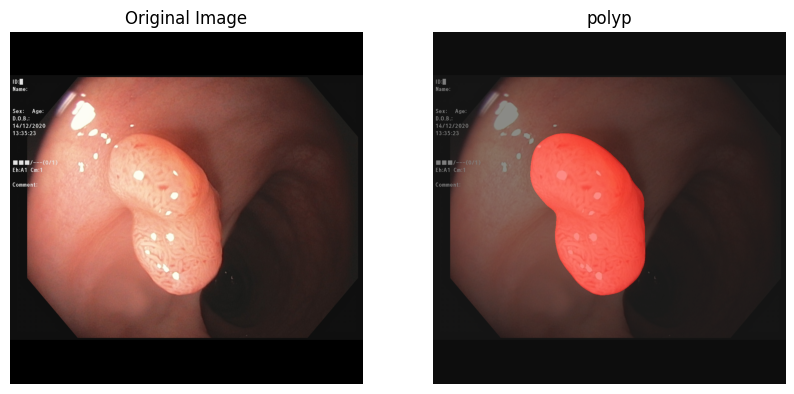

polyp P-value: 0.2868272081328177


In [13]:
image_path = 'examples/C3_EndoCV2021_00462.jpg'
text_prompt = ['polyp']

image, pred_mask = inference_rgb(image_path, text_prompt)

for i in range(len(pred_mask)):
    adj_pvalue = check_mask_stats(image, pred_mask[i]*255, 'Endoscopy', text_prompt[i])
    print(f'{text_prompt[i]} P-value: {adj_pvalue}')

### Dermoscopy Example

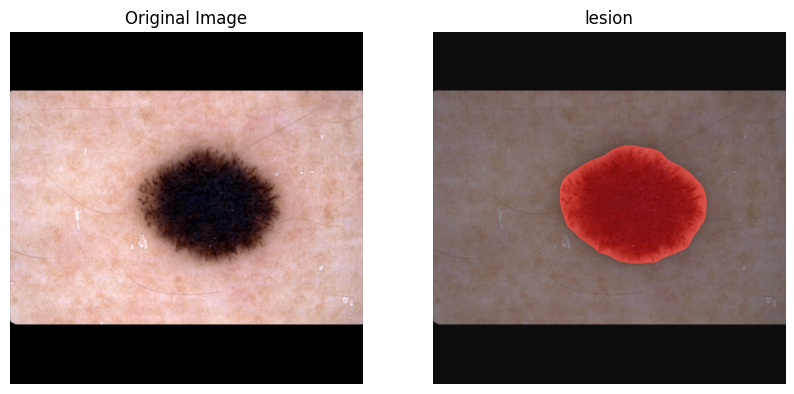

lesion P-value: 0.1364192416037776


In [14]:
image_path = 'examples/ISIC_0015551.jpg'
text_prompt = ['lesion']

image, pred_mask = inference_rgb(image_path, text_prompt)

for i in range(len(pred_mask)):
    adj_pvalue = check_mask_stats(image, pred_mask[i]*255, 'Dermoscopy', text_prompt[i])
    print(f'{text_prompt[i]} P-value: {adj_pvalue}')

### OCT Example

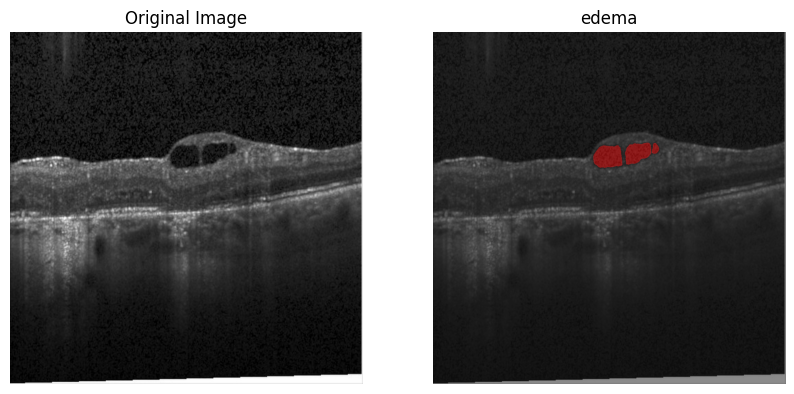

edema P-value: 0.3362608490858501


In [15]:
image_path = 'examples/144DME_as_F.jpeg'
text_prompt = ['edema']

image, pred_mask = inference_rgb(image_path, text_prompt)

for i in range(len(pred_mask)):
    adj_pvalue = check_mask_stats(image, pred_mask[i]*255, 'OCT', text_prompt[i])
    print(f'{text_prompt[i]} P-value: {adj_pvalue}')

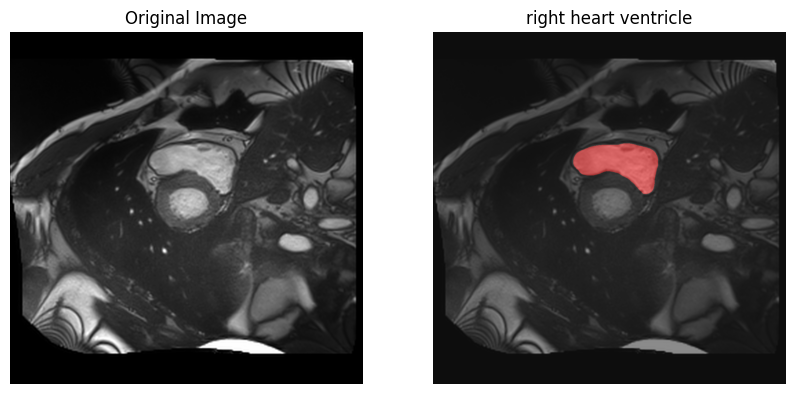

right heart ventricle P-value: 0.4197858307801669


In [16]:
image_path = '/home/t-qimhuang/code/BiomedParse-v2/08_MRI_heart.png'
text_prompt = ['right heart ventricle']

image, pred_mask = inference_rgb(image_path, text_prompt)

for i in range(len(pred_mask)):
    adj_pvalue = check_mask_stats(image, pred_mask[i]*255, 'MRI-Cardiac', text_prompt[i])
    print(f'{text_prompt[i]} P-value: {adj_pvalue}')